In [112]:
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('personality_dataset.csv')

In [113]:
print(df.describe(include=['number']))
df.describe(include=['object'])
df.dtypes

       Time_spent_Alone  Social_event_attendance  Going_outside  \
count       2837.000000              2838.000000    2834.000000   
mean           4.505816                 3.963354       3.000000   
std            3.479192                 2.903827       2.247327   
min            0.000000                 0.000000       0.000000   
25%            2.000000                 2.000000       1.000000   
50%            4.000000                 3.000000       3.000000   
75%            8.000000                 6.000000       5.000000   
max           11.000000                10.000000       7.000000   

       Friends_circle_size  Post_frequency  
count          2823.000000     2835.000000  
mean              6.268863        3.564727  
std               4.289693        2.926582  
min               0.000000        0.000000  
25%               3.000000        1.000000  
50%               5.000000        3.000000  
75%              10.000000        6.000000  
max              15.000000       10.

Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

<Axes: >

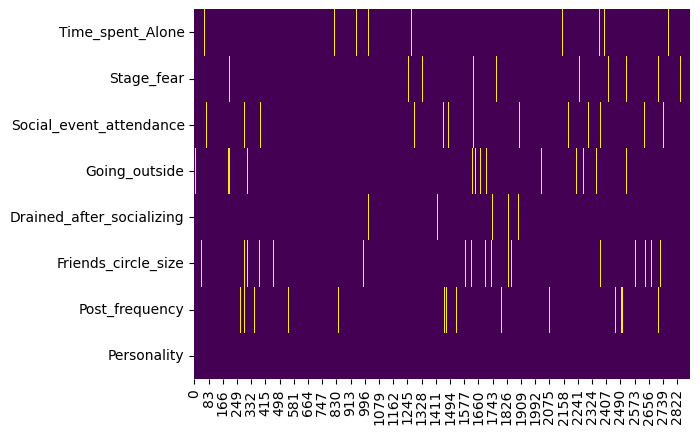

In [114]:
sns.heatmap(df.isna().T, cbar=False, cmap='viridis')

In [115]:
df['Stage_fear'] = df['Stage_fear'].replace({'Yes': 1, 'No': 0})
df['Stage_fear'] = df['Stage_fear'].astype('int8')

/var/folders/ll/2dw3c8w16bq4l6d2zkwh1ct40000gn/T/ipykernel_2079/2957923688.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stage_fear'] = df['Stage_fear'].replace({'Yes': 1, 'No': 0})


IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [10]:
df['Drained_after_socializing'] = df['Drained_after_socializing'].replace({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].astype('int8')

In [17]:
# Make Extroverted equal to 1 if Personality is Extroverted, else 0
df['Extroverted'] = df['Personality']
df['Extroverted'] = df['Extroverted'].replace({'Extrovert': 1, 'Introvert': 0})
df['Extroverted'] = df['Extroverted'].astype('int8')

/var/folders/ll/2dw3c8w16bq4l6d2zkwh1ct40000gn/T/ipykernel_2079/255189474.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Extroverted'] = df['Extroverted'].replace({'Extrovert': 1, 'Introvert': 0})


['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Drained_after_socializing', 'Friends_circle_size', 'Post_frequency', 'Personality'] []


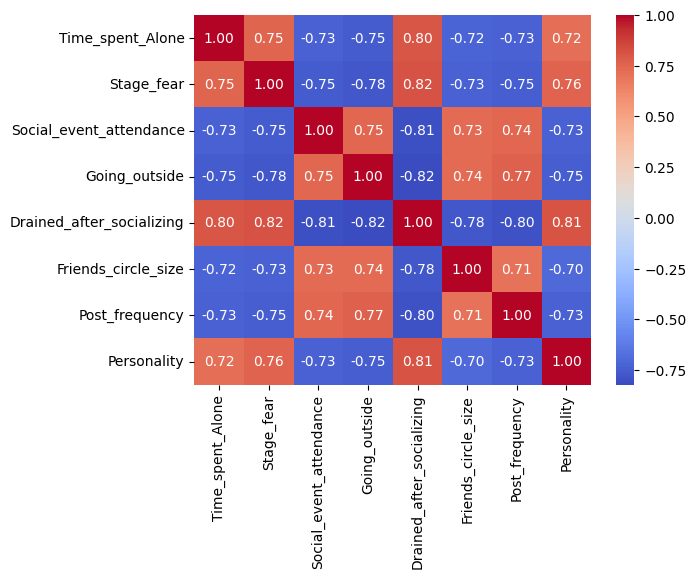

In [57]:
numeric = df.select_dtypes(include=[np.number]).columns.tolist()
categoric = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Correlation matrix
corr = df[numeric].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
print(numeric, categoric)

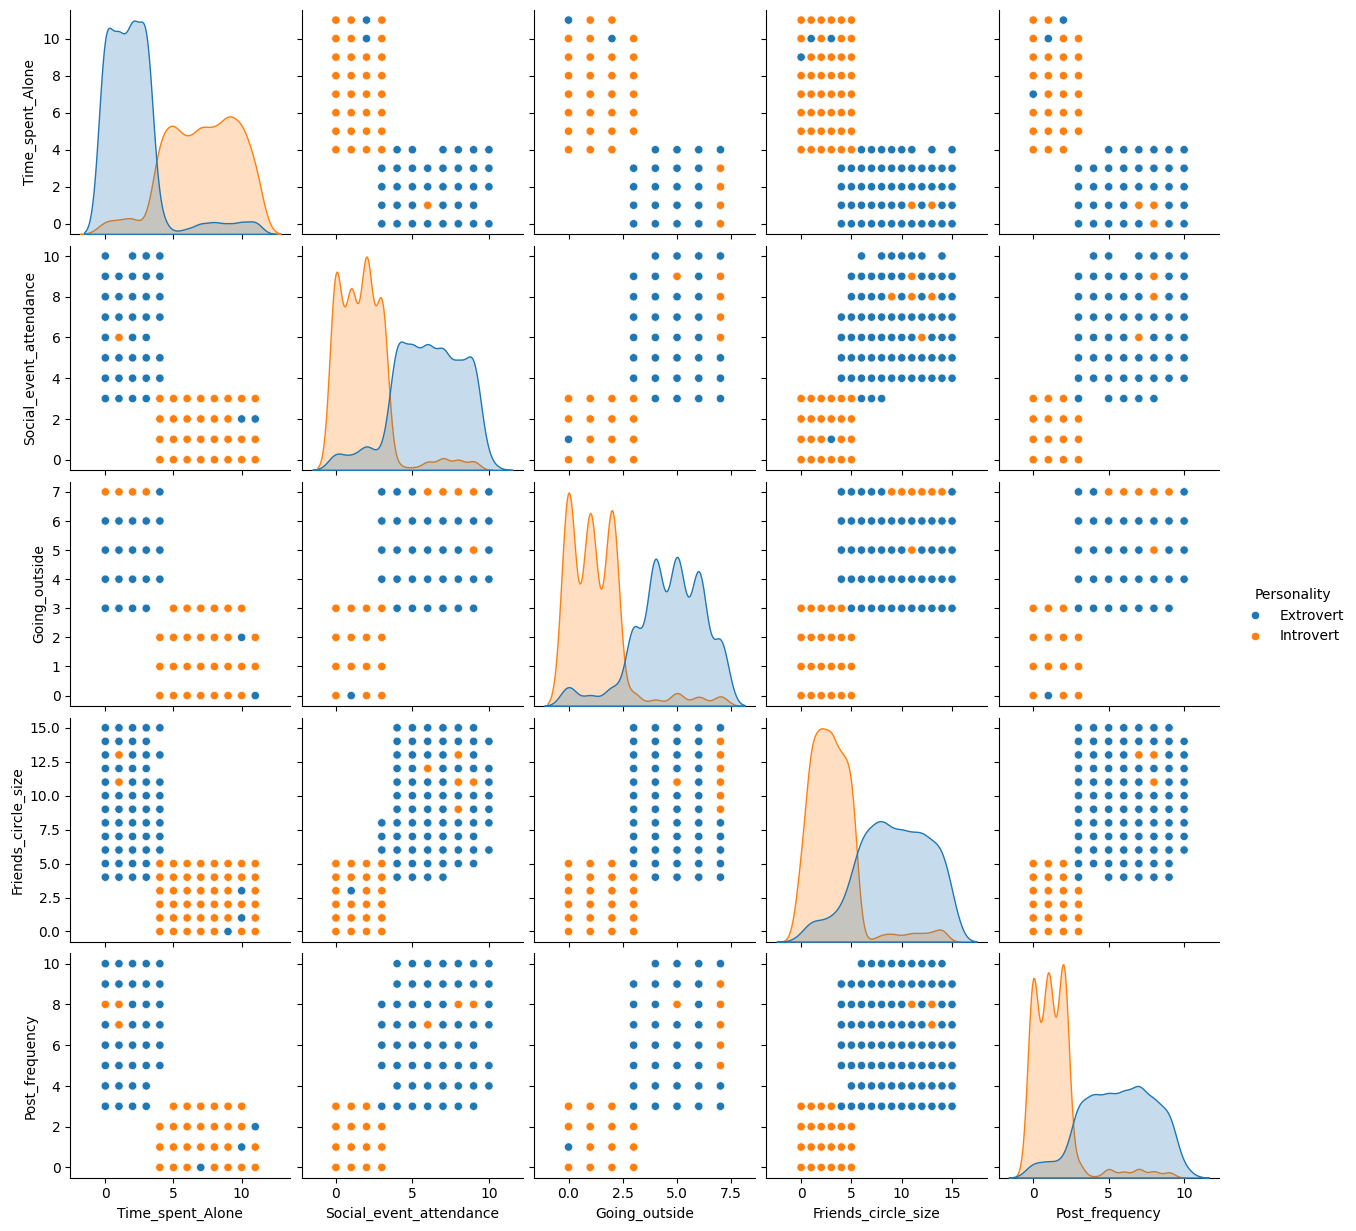

In [36]:
sns.pairplot(df, hue='Personality', diag_kind='kde'
             
             )

In [38]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in categoric:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [125]:
# IMplement XGBoost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Personality'])
y = df['Personality']
y = pd.DataFrame([1 if y_ == 'Extrovert' else 0 for y_ in y])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
# model.fit(X_train, y_train)

# from sklearn.metrics import classification_report, accuracy_score
# from sklearn.metrics import confusion_matrix
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred))
# print("Accuracy:", accuracy_score(y_test, y_pred))
# print(confusion_matrix(y_test, model.predict(X_test)))

In [126]:
y_train.head()


,0
2078,1
163,0
1938,0
252,0
2232,0


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV

# Define preprocessing for numeric and categorical features
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
# Create a pipeline with preprocessing and model
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'))
])
# Define the parameter grid for GridSearchCV
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}
# Perform GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)
# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Test set accuracy:", accuracy_score(y_test, y_pred_best))
# Visualize feature importances
import matplotlib.pyplot as plt
importances = best_model.named_steps['classifier'].feature_importances_
feature_names = numeric_features + categorical_features
indices = np.argsort(importances)[::-1]

/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:13:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:13:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:13:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:13:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters:

Best parameters: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 50}
Best cross-validation score: 0.9344827586206896
Test set accuracy: 0.9275862068965517


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:13:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [19:13:47] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [120]:
numeric_features = X_train.select_dtypes(include=['number']).columns.to_list()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.to_list()

print(numeric_features)
print(categorical_features)

['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance', 'Going_outside', 'Friends_circle_size', 'Post_frequency']
['Drained_after_socializing']


In [127]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

numeric_features = X_train.select_dtypes(include=['number']).columns.to_list()
categorical_features = X_train.select_dtypes(exclude=['number']).columns.to_list()

numeric_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder())
    ]
)

preprocessor = ColumnTransformer(
    [
        ('numeric_transformer', numeric_transformer, numeric_features),
        ('categorical_transformer', categorical_transformer, categorical_features)
    ]
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric='mlogloss'))
])

pipeline.fit(X_train, y_train)

preds = pipeline.predict(X_test)

CV_model = GridSearchCV(
    pipeline,
    param_grid = {'classifier__max_depth': [2, 4, 6, 10],
                  'classifier__learning_rate': [0.01, 0.05, 0.1]},
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)

CV_model.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numeric_transformer',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Time_spent_Alone',
                                                                          'Stage_fear',
                                                                          'Social_event_attendance',
                                                                          'Going_outside',
                                                                          'Friends_circle_size',
                                                                          'Post_frequency']),
                                                                        ('categorical_transformer',
                                                                         P...
                                                      max_cat_threshold=None,
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.01, 0.05, 0.1],
                         'classifier__max_depth': [2, 4, 6, 10]},
             scoring='accuracy')

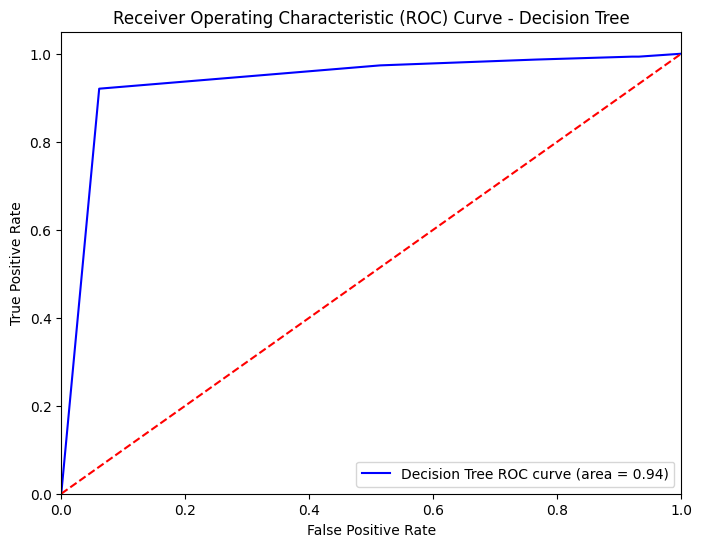

In [128]:
probs = CV_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report, accuracy_score, auc

fpr, tpr, tresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Decision Tree ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Decision Tree')
plt.legend(loc='lower right')
plt.show()



In [134]:
X_test.shape

(580, 7)

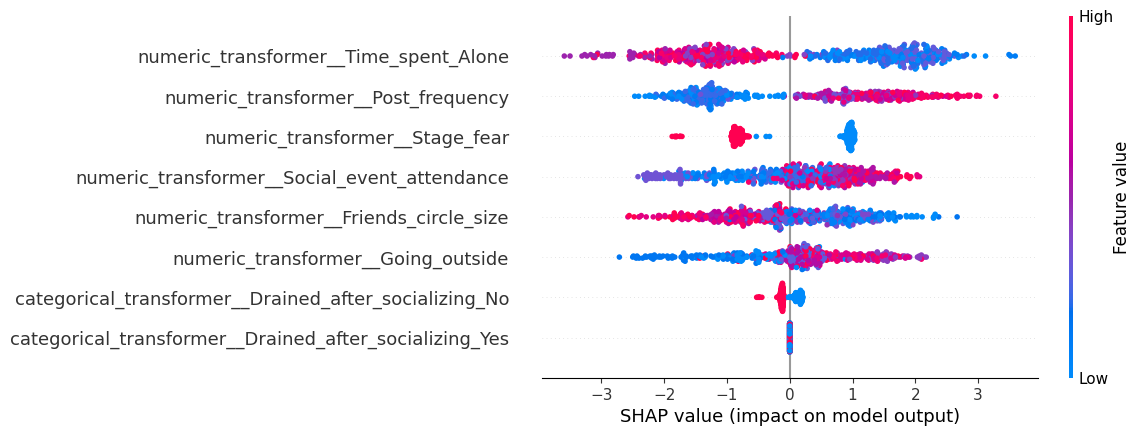

In [143]:
import shap
# Separate the preprocessor and classifier
preprocessor = pipeline.named_steps['preprocessor']
model = pipeline.named_steps['classifier']

# Dynamically get feature names after transformation
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# Create the DataFrame with the correct number of columns
X_transformed_df = pd.DataFrame(
    pipeline.named_steps['preprocessor'].transform(X_test),
    columns=feature_names
)
# Create the SHAP explainer using the model and transformed features
explainer = shap.Explainer(model, X_transformed_df)

# Compute SHAP values
shap_values = explainer(X_transformed_df)

# Plot violin/beeswarm
shap.plots.beeswarm(shap_values)


In [111]:
y_test.head()

141     1
1557    0
485     1
1712    1
2250    1
Name: Personality, dtype: int64

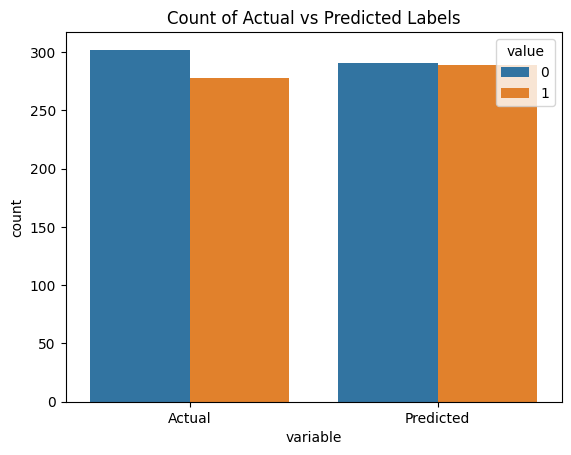

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': preds
})

sns.countplot(data=df.melt(), x='variable', hue='value')
plt.title('Count of Actual vs Predicted Labels')
plt.show()

In [147]:
X_train.head()
X_train2 = X_train.copy()

X_train2['Drained_after_socializing'] = [1 if X_=='Yes' else 0 for X_ in X_train['Drained_after_socializing']]

In [148]:
X_train2.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency
2078,3.0,0.0,5.0,6.0,0,10.0,9.0
163,6.0,1.0,3.0,3.0,1,1.0,0.0
1938,10.0,1.0,2.0,2.0,1,1.0,0.0
252,9.0,1.0,1.0,2.0,1,3.0,1.0
2232,10.0,1.0,0.0,0.0,1,4.0,1.0


In [162]:
GLMtrain = pd.concat([X_train2, y_train], axis=1)

GLMtrain.columns.values[-1] = 'Extrovert'
GLMtrain.head()
print(GLMtrain.columns)
GLMtrain_filled = GLMtrain.fillna(GLMtrain.median())

Index(['Time_spent_Alone', 'Stage_fear', 'Social_event_attendance',
       'Going_outside', 'Drained_after_socializing', 'Friends_circle_size',
       'Post_frequency', 'Extrovert'],
      dtype='object')


# GLM

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

ols = smf.ols(formula="Extrovert ~ Stage_fear + Social_event_attendance + Going_outside + Drained_after_socializing + Friends_circle_size + Post_frequency", data=GLMtrain_filled).fit()
ols.summary()

In [177]:
glm = smf.glm(
    formula="Extrovert ~ Stage_fear + Drained_after_socializing",
    data=GLMtrain_filled,
    family=sm.families.Binomial()
).fit()

glm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              Extrovert   No. Observations:                 2320
Model:                            GLM   Df Residuals:                     2317
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -589.62
Date:                Sat, 07 Jun 2025   Deviance:                       1179.2
Time:                        11:03:34   Pearson chi2:                 2.32e+03
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5841
Covariance Type:            nonrobust                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept                     2.6545      0.116     22.949      0.000       2.428       2.881
Stage_fear                   -2.6464      0.285     -9.286      0.000      -3.205      -2.088
Drained_after_socializing    -2.6464      0.285     -9.286      0.000      -3.205      -2.088
=============================================================================================
"""

In [186]:
GLMtest_filled = pd.concat([X_test, y_test], axis=1)
GLMtest_filled.columns.values[-1] = 'Extrovert'
GLMtest_filled.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Extrovert
141,10.0,1.0,3.0,3.0,Yes,5.0,3.0,0
1557,NaN,0.0,NaN,5.0,No,14.0,5.0,1
485,5.0,1.0,0.0,0.0,Yes,0.0,2.0,0
1712,10.0,1.0,2.0,2.0,Yes,2.0,1.0,0
2250,7.0,1.0,0.0,0.0,Yes,2.0,1.0,0


In [ ]:
GLMtest_filled['Drained_after_socializing'] = [1 if y_ == "Yes" else 0 for y_ in GLMtest_filled['Drained_after_socializing']]
GLMtest_filled = GLMtest_filled.fillna(GLMtest_filled.median())

In [ ]:
glm_probs = glm.predict(GLMtest_filled)
glm_labels = (glm_probs >= 0.5).astype('int8')

from sklearn.metrics import accuracy_score, classification_report

print(classification_report(GLMtest_filled['Extrovert'], glm_labels))


              precision    recall  f1-score   support

           0       0.91      0.91      0.91       278
           1       0.91      0.92      0.92       302

    accuracy                           0.91       580
   macro avg       0.91      0.91      0.91       580
weighted avg       0.91      0.91      0.91       580



# Regularized GLM


In [218]:
glm_base = sm.GLM(y, X, family=sm.families.Binomial())

lasso_glm = glm_base.fit_regularized(method='elastic_net', alpha=0.1, L1_wt=0.6)

In [219]:
probs_lasso = lasso_glm.predict(X)
labels_lasso = (probs_lasso >= 0.5).astype('int8')

print(pd.Series(lasso_glm.params, index=X.columns))

Intercept                    0.423796
Stage_fear                  -0.741168
Drained_after_socializing   -0.741168
dtype: float64
